# Introduction: Non-singlet PDF Neural Network Training

This notebook constructs a physics-informed neural network (PINN) to model parton distribution functions (PDFs) learned from data and DGLAP residuals. To begin, we focus on modeling the non-singlet valence up-quark (UV) PDF at Q^2 = 1.6129, 10, 100, 500, & 1000 from JAM data and the DGLAP equations.

Updates in this notebook:
* This version of the PDF PINN includes the valence sum rule as an additional constraint, which is a separate loss function term. Reference: [NNPDF Collaboration](https://arxiv.org/pdf/2109.02653), section 3.1.2

# DGLAP Equations Background


The DGLAP (Dokshitzer-Gribov-Lipatov-Altarelli-Parisi) equations handle flavor singlet and non-singlet distributions differently because of gluon coupling.
Here is how the mathematics and physics split between the two categories.
## 1. Non-Singlet Evolution (Decoupled)
Non-singlet distributions describe quantities that carry flavor quantum numbers, such as valence quark distributions ($q_i - \bar{q}_i$) or differences between flavors ($u - d$). [1]

* No Gluon Mixing: Gluons carry no flavor. They cannot directly split into or absorb a specific flavor excess.
* Independent Evolution: Each non-singlet distribution evolves entirely on its own.
* The Equation: It is a single, isolated differential equation:
$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y, Q^2)$$
* Splitting Function: It only requires the quark-to-quark splitting function ($P_{qq}$). [2]

## 2. Singlet Evolution (Coupled Matrix)
The flavor singlet distribution ($\Sigma$) is the sum of all quarks and antiquarks across all active flavors. It represents the total quark density.

* Direct Gluon Mixing: Quarks can radiate gluons, and gluons can split into quark-antiquark pairs. Total quark density and gluon density directly drive each other.
* Matrix Evolution: The equations become a system of two coupled differential equations.
* The Equation: It must be solved simultaneously using a $2 \times 2$ matrix of splitting functions:
$$\frac{d}{d \ln Q^2} \begin{pmatrix} \Sigma(x, Q^2) \\ g(x, Q^2) \end{pmatrix} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} \begin{pmatrix} P_{qq} & 2n_f P_{qg} \\ P_{gq} & P_{gg} \end{pmatrix}\left(\frac{x}{y}\right) \begin{pmatrix} \Sigma(y, Q^2) \\ g(y, Q^2) \end{pmatrix}$$
* Splitting Functions: It requires four functions ($P_{qq}, P_{qg}, P_{gq}, P_{gg}$) and depends on the number of active flavors ($n_f$). [3, 4, 5, 6, 7]

## Key Physical Consequence
As momentum scale ($Q^2$) increases, gluons rapidly split into sea quarks. This causes the singlet distribution to grow explosively at low $x$ values.
In contrast, the non-singlet distribution (like your $u$ valence distribution) does not receive these gluon contributions, causing its total area to remain strictly conserved. [8]





[1] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/1361-6471/ac11c1)
[2] [https://journals.aps.org](https://journals.aps.org/prd/accepted/10.1103/4jvb-24hk)
[3] [https://link.springer.com](https://link.springer.com/article/10.1140/epjc/s10052-026-15417-5)
[4] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/0256-307X/40/9/091201)
[5] [https://link.aps.org](https://link.aps.org/doi/10.1103/2d8y-ljwx)
[6] [https://arxiv.org](https://arxiv.org/html/2604.09534v2)
[7] [https://link.aps.org](https://link.aps.org/doi/10.1103/PhysRevD.110.114011)
[8] [https://www.mdpi.com](https://www.mdpi.com/2571-712X/6/1/15)
[9] [https://ar5iv.labs.arxiv.org](https://ar5iv.labs.arxiv.org/html/1111.5452)



The explicit form of the unpolarized, leading-order (LO) splitting function for flavor non-singlet evolution describes the probability of a quark radiating a gluon and remaining a quark.
## The Explicit Formula
At leading order (one-loop), the non-singlet splitting function $P_{qq}(z)$ is given by:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
## Key Components Explained

* Color Factor ($C_F$): This represents the color charge of a quark in QCD. Its value is exactly $C_F = \frac{4}{3}$.
* Momentum Fraction ($z$): This is the fraction of the parent quark’s longitudinal momentum retained by the daughter quark after radiating the gluon.
* The Plus-Prescription ($+$): The term $\frac{1}{(1-z)_+}$ is a mathematical distribution used to regularize the infrared divergence that occurs when a gluon is emitted with zero energy ($z \to 1$). It is defined via its integration behavior with a test function $f(z)$:
$$\int_0^1 \frac{f(z)}{(1-z)_+} dz = \int_0^1 \frac{f(z) - f(1)}{1-z} dz$$
* Delta Function ($\delta$): The $\frac{3}{2}\delta(1-z)$ term accounts for virtual gluon corrections (loop diagrams) where no physical gluon is emitted, balancing the real emission divergence.

## The Regularized Alternative Form
You will frequently see this written in an alternative, mathematically equivalent form that avoids the plus-prescription by explicitly grouping the virtual and real emission terms:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
When integrated inside the DGLAP equation, it physically simplifies to:
$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$
## Physical Interpretation

* Soft Gluon Divergence: The denominator $(1-z)$ shows that a quark is highly likely to lose a very small amount of momentum to a “soft” gluon.
* Quark Number Conservation: If you integrate $P_{qq}(z)$ from 0 to 1, the result is exactly zero ($\int_0^1 P_{qq}(z)dz = 0$). This mathematical property guarantees that the total number of valence quarks is strictly conserved during QCD evolution, even as the momentum distribution changes shape.








# PINN Model

## Imports & Auxillary Dictionary

Here we import necessary libraries for neural network construction, data interpolation, and plotting. We also set a seed to ensure network training reproducibility.

The auxillary class is used as a dictionary to store variables used to calculate the alpha_s, the strong coupling factor.

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import copy
import time
import random
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.interpolate import CubicSpline
from mpmath import fp

SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
class AUX:

    def __init__(self):

        #--set_constants

        self.CA=3.0
        self.CF=4.0/3.0
        self.TR=0.5
        self.TF=0.5
        self.euler=fp.euler

        #--set_masses

        self.me   = 0.000511
        self.mm   = 0.105658
        self.mt   = 1.77684
        self.mu   = 0.055
        self.md   = 0.055
        self.ms   = 0.2
        self.mc   = 1.28
        self.mb   = 4.18

        self.mZ   = 91.1876
        self.mW   = 80.398
        self.M    = 0.93891897
        self.Mpi  = 0.13803
        self.Mk   = 0.493677
        self.Mdelta = 1.232

        self.me2   = self.me**2
        self.mm2   = self.mm**2
        self.mt2   = self.mt**2
        self.mu2   = self.mu**2
        self.md2   = self.md**2
        self.ms2   = self.ms**2
        self.mc2   = self.mc**2
        self.mb2   = self.mb**2
        self.mZ2   = self.mZ**2
        self.mW2   = self.mW**2
        self.M2    = self.M**2
        self.Mpi2  = self.Mpi**2
        self.Mdelta2=self.Mdelta**2

        #--set_couplings

        self.c2w   = self.mW2/self.mZ2
        self.s2w   = 1.0-self.c2w
        self.s2wMZ = 0.23116
        self.c2wMZ = 1.0 - self.s2wMZ
        self.alfa  = 1/137.036
        self.alphaSMZ = 0.118
        self.GF = 1.1663787e-5   # 1/GeV^2

## Load Data & Define Running Coupling

The PDF data set is sourced from trey24_no_sidis_lo.npy, which contains PDFs at Q^2 = 1.6129, 10, 100, 500, and 1000. At each Q^2 value, there are 200 x points, with 1196 replicas each.

Since this data is set on a hybrid log/linear grid, we interpolate the data onto a purely log-spaced grid, using CubicSpline. This allows us to employ Simpson's Rule, which requires equally spaced quadrature points, to numerically approximate the DGLAP convolution.  

We only interpolate the PDF medians, 2.5th percentile, and 97.5th percentile onto the log grid to obtain a band where 95% of the JAM PDF replicas fall.

The running coupling is then defined and used to precompute alpha_s for each Q^2 value, which will be used later to calculate the DGLAP convolution.

In [ ]:
# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/colab_notebooks/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

# Original hybrid grid
X_orig = 10**np.linspace(-4, np.log10(0.4), 100)
X_orig = np.append(X_orig, np.linspace(0.4, 1, 101)[1:])

# upper limit tightened from 0.999 to (1 - 1e-6) for consistency
# with the virtual term domain log(1-x). Both now approach x=1 equally.
N_x = 1000
X   = np.logspace(-4, np.log10(1 - 1e-6), N_x)

Q2_vals = [1.6129, 10, 100, 500, 1000]
VAL_Q2  = 500.0
CF = 4.0 / 3.0

# Interpolate JAM median and 95% replica bands onto the log grid X.
treypdf_log = {}
for q2 in Q2_vals:
    uv_reps        = treypdf[q2]['uv']
    uv_median_orig = np.median(uv_reps, axis=0)
    uv_lo_orig     = np.quantile(uv_reps, 0.025, axis=0)     # 2.5th percentile
    uv_hi_orig     = np.quantile(uv_reps, 0.975, axis=0)     # 97.5th percentile

    cs_med = CubicSpline(X_orig, uv_median_orig)
    cs_lo  = CubicSpline(X_orig, uv_lo_orig)
    cs_hi  = CubicSpline(X_orig, uv_hi_orig)

    treypdf_log[q2] = {
        'uv'    : cs_med(X),   # median on log grid
        'uv_lo' : cs_lo(X),    # 2.5th percentile on log grid
        'uv_hi' : cs_hi(X),    # 97.5th percentile on log grid
    }

print(f'N_x: {N_x} (log-spaced grid: {X.min():.2e} to {X.max():.6f})')



Device: cuda
Mounted at /content/drive
N_x: 1000 (log-spaced grid: 1.00e-04 to 0.999999)


In [ ]:
class ALPHAS:

    def __init__(self,order=1):
        """
        order=0: 1-loop
        order=1: 2-loops
        """
        if 'order' in conf: order=conf['order']
        self.order=order
        self.mu20=1
        self.setup()

    def setup(self):
        aux = conf['aux']

        #--setup the beta function
        self.beta=np.zeros((7,3))
        for Nf in range(3,7):
            self.beta[Nf,0]=11.0-2.0/3.0*Nf
            self.beta[Nf,1]=102.-38.0/3.0*Nf
            self.beta[Nf,2]=2857.0/2.0-5033.0/18.0*Nf+325.0/54.0*Nf**2

        # uses alphaS(mZ)--> backwards evolution
        self.aZ  = conf['aux'].alphaSMZ/(4*np.pi)
        self.ab=self.evolve_a(self.aZ,aux.mZ2,aux.mb2,5)
        self.ac=self.evolve_a(self.ab,aux.mb2,aux.mc2,4)
        self.a0=self.evolve_a(self.ac,aux.mc2,self.mu20,3)

        # we will store all Q2 values of alphaS
        self.storage={}


    def get_Nf(self,mu2):
        aux = conf['aux']
        Nf=3
        if mu2>=(aux.mc2): Nf+=1
        if mu2>=(aux.mb2): Nf+=1
        return Nf

    def beta_func(self,a,Nf):
        betaf = -self.beta[Nf,0]
        if self.order>=1: betaf+=-a*self.beta[Nf,1]
        if self.order>=2: betaf+=-a*self.beta[Nf,2]
        return betaf*a**2

    def evolve_a(self,a0,mu20,mu2,Nf):
        # Runge-Kutta implemented in pegasus
        LR = np.log(mu2/mu20)/20.0
        a=a0
        for k in range(20):
            XK0 = LR * self.beta_func(a,Nf)
            XK1 = LR * self.beta_func(a + 0.5 * XK0,Nf)
            XK2 = LR * self.beta_func(a + 0.5 * XK1,Nf)
            XK3 = LR * self.beta_func(a + XK2,Nf)
            a+= (XK0 + 2.* XK1 + 2.* XK2 + XK3) * 0.166666666666666
        return a

    def get_a(self,mu2):
        aux = conf['aux']

        if mu2 not in self.storage:

            if aux.mb2<=mu2:
                mu20,a0,Nf=aux.mb2,self.ab,5
            elif aux.mc2<=mu2 and mu2<aux.mb2:
                mu20,a0,Nf=aux.mc2,self.ac,4
            elif mu2<aux.mc2:
                mu20,a0,Nf=self.mu20,self.a0,3
            self.storage[mu2]=self.evolve_a(a0,mu20,mu2,Nf)

        return self.storage[mu2]

    def get_alphaS(self,mu2):
        return self.get_a(mu2)*4*np.pi

conf = {}
conf['aux']   = AUX()
conf['order'] = 0    # LO running: one-loop beta function, consistent with LO splitting function
mu2=conf['aux'].mZ2

alphas_runner = ALPHAS()


In [ ]:
# Precompute running alpha_s for all training Q² values.
# get_alphaS returns a Python float; convert to float32 scalar tensor
# for use inside dglap_convolution which operates in torch.
alphas_Q2 = {
    q2: torch.tensor(alphas_runner.get_alphaS(q2), dtype=torch.float32, device=device)
    for q2 in Q2_vals
}

print('Running alpha_s values:')
for q2, a in alphas_Q2.items():
    print(f'  Q² = {q2:>8.4f} GeV²  →  alpha_s = {a.item():.6f}')

Running alpha_s values:
  Q² =   1.6129 GeV²  →  alpha_s = 0.319246
  Q² =  10.0000 GeV²  →  alpha_s = 0.230247
  Q² = 100.0000 GeV²  →  alpha_s = 0.173084
  Q² = 500.0000 GeV²  →  alpha_s = 0.147941
  Q² = 1000.0000 GeV²  →  alpha_s = 0.139230


## Build Training/Validation Tensors & Define Collocation Points

The training and valiation tensors are then constructed using the interpolated data. The neural network target will be the JAM UV medians at Q^2=1.6129, which serves as the boundary condition and guides the network in the PDF's kinematic dependence.

The network input is (x, ln(x), ln(Q^2)), and the output is xf(x, Q^2).

PDF data at Q^2=500 is used to build a validation tensor, which will indicate the network's ability to generalize to unseen data.

The collocation grid includes all x data points. This grid defines (x, Q^2) points where the DGLAP covolution will be evaluated.

In [ ]:

# ── 2. Build train / val tensors using interpolated data ───────────────────
log_x = np.log(X)

train_inp, train_tgt = [], []
val_inp,   val_tgt   = [], []

# Define the Q^2 values to use for data training
DATA_TRAIN_Q2_VALS = [1.6129]

for q2 in Q2_vals:
    uv_median = treypdf_log[q2]['uv']
    log_q2    = np.full(N_x, np.log(q2))
    inp       = np.stack([X, log_x, log_q2], axis=1) # Stack X, ln(X), and ln(Q^2) as input features
    tgt       = uv_median[:, None]

    if q2 in DATA_TRAIN_Q2_VALS:
        train_inp.append(inp)
        train_tgt.append(tgt)
    elif q2 == VAL_Q2:
        val_inp.append(inp)
        val_tgt.append(tgt)

train_X = torch.tensor(np.concatenate(train_inp), dtype=torch.float32).to(device)
train_Y = torch.tensor(np.concatenate(train_tgt), dtype=torch.float32).to(device)
val_X   = torch.tensor(np.concatenate(val_inp),   dtype=torch.float32).to(device)
val_Y   = torch.tensor(np.concatenate(val_tgt),   dtype=torch.float32).to(device)

print(f'train_X: {train_X.shape}  val_X: {val_X.shape}')

train_X: torch.Size([1000, 3])  val_X: torch.Size([1000, 3])


In [ ]:
# ── 3. Collocation points ────────────────────────────────────────────────────
#
#  Reuse the training Q² values and the same x grid.
#  VAL_Q2=500 is explicitly excluded so the validation Q² receives
#  no physics-based gradient signal during training.

colloc_inp_list = []

for q2 in Q2_vals:
    if q2 == VAL_Q2:
        continue
    log_q2_col = np.full(N_x, np.log(q2))
    inp        = np.stack([X, log_x, log_q2_col], axis=1)   # (N_x, 3) # Stack X, ln(X), and ln(Q^2) for collocation input
    colloc_inp_list.append(inp)

# Shape: (N_train_Q2 * N_x, 3)  — 4 Q² values × 200 x points = 800 rows
colloc_np = np.concatenate(colloc_inp_list)
colloc_X  = torch.tensor(colloc_np, dtype=torch.float32).to(device)

# x_grid as a tensor — needed for Simpson convolution
x_grid_t  = torch.tensor(X, dtype=torch.float32).to(device)

print(f'Collocation grid: {colloc_X.shape}')

Collocation grid: torch.Size([4000, 3])


## Define Weights for Simpson's Rule Implementation

Next, we define quadrature weights to numerically approximate the DGLAP convolution integral with Simpson's Rule. Specifically, we use the Composite Simpson's 1/3 Rule:

$$\int_{a}^{b} f(x) dx \approx \frac{\Delta x}{3} \left[ f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \dots + f(x_n) \right]$$

This rule requires the integration intervals (or quadrature points since it uses the left point, midpoint, and right point) to be uniformly spaced. For this reason, we interpolated the data onto a log-spaced grid. Originally, the convolution integral involves an integral over $y$ with the measure $dy/y$:

$$\int_x^1 \frac{dy}{y} P(x/y) f(y)$$

But now, we can define $t = \ln(y)$.
By taking the derivative of t, you get $dt = \frac{1}{y} dy$, so the measure $\frac{dy}{y}$ is exactly equal to $dt$.



Since the integration variable $y$ travels along this same grid, the 'step size' in $t$-space ($dt$) is a constant:

$$\Delta t = \ln(x_{i+1}) - \ln(x_i) = \text{constant}$$

This allows us to apply uniform Simpson weights to the quadrature points. However, since our grid contains an even number of points, but Simpson's 1/3 rule requires an odd number of points (3 points for each interval), there remains the final interval between the last two points. To account for this last interval, we apply the Trapezoidal Rule, in which the weight for a single interval of width $\Delta$ is $\frac{\Delta}{2}$ for each endpoint.



In [ ]:
# ── 4. Uniform Simpson weights (log-space integration) ───────────────────────

def build_log_simpson_weights(N, delta_lnx):
    """
    Composite Simpson weights for a uniform grid in ln(y) space.

    Integration variable: t = ln(y), uniform spacing delta_lnx in log space.
    Composite Simpson pattern for N points:
    [1, 4, 2, 4, 2, ..., 4, 2, 4, 1] × (delta_lnx / 3)
    For even N (N=200), N-1=199 points cover an even number of intervals (198).
    The last interval [N-2, N-1] uses the trapezoid fallback.

    The trapezoid then adds delta_lnx/2 to both w[N-2] and w[N-1],
    so w[N-2] correctly accumulates Simpson (delta_lnx/3) + trap (delta_lnx/2).
    """
    w = torch.zeros(N)

    # ── Composite Simpson over first N-1 points (indices 0 to N-2) ───────
    w[0]       = 1.0          # left endpoint
    w[1:N-2:2] = 4.0          # odd interior indices (midpoints of each pair)
    w[2:N-2:2] = 2.0          # even interior indices (shared endpoints)
    w[N-2]     = 1.0          # right endpoint
    w = w * (delta_lnx / 3.0)

    # ── Trapezoid fallback for final interval [N-2, N-1] ─────────────────
    w[N-2] += delta_lnx / 2.0
    w[N-1]  = delta_lnx / 2.0  # right endpoint

    return w

# assert log spacing is truly uniform before using uniform-h formula
log_X     = np.log(X)
spacings  = np.diff(log_X)
assert np.allclose(spacings, spacings[0], rtol=1e-6), \
    'Grid is not uniform in log space — switch to non-uniform weights'
delta_lnx = float(spacings[0])

simp_weights = build_log_simpson_weights(N_x, delta_lnx).to(device)

print(f'delta_lnx:            {delta_lnx:.8f}')
print(f'Weights sum:          {simp_weights.sum().item():.6f}')
print(f'Expected (ln range):  {log_X[-1] - log_X[0]:.6f}')


delta_lnx:            0.00921956
Weights sum:          9.210340
Expected (ln range):  9.210339


## NS Splitting Function & DGLAP Convolution

Previously we defined the LO non-singlet splitting function $P_{qq}(z)$ as:

$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$


We then examined a regularized alternative form
:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$

Which, when integrated inside the DGLAP equation, becomes:

$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$

Below, we define the LO NS splitting function for the real-emission term. In the denominator, we add an epsilon term of $\frac{\Delta ln(x)}{2}$ to prevent numerical near-division-by-zero when z is very close to 1.

In [ ]:
# ── 5. LO non-singlet splitting function ─────────────────────────────────────

def P_qq_kernel(z):
    """
    Real-emission part of LO P_qq: (1 + z²) / (1 - z).
    C_F applied in dglap_convolution.
    Singularity at z=1 regulated by [f(y)-z*f(x)] subtraction.
    z : tensor, any shape, values in (0, 1)
    """
    return (1 + z**2) / (1 - z + 0.5*delta_lnx)

Now, we define a function to numerically approximate the RHS of the NS DGLAP equation at LO:

$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} C_F
\left[
    \int_{\ln x}^{0}
    \frac{1 + \left(\frac{x}{e^t}\right)^2}{1 - \frac{x}{e^t}}
    \left[ f(e^t) - \frac{x}{e^t}\, f(x) \right] dt
    + \left( \frac{3}{2} + 2\ln(1-x) \right) f(x)
\right]$$

To perform the integration, we mask y > xi since the integration is performed from x to 1 (or ln(x) to 0). This mask ensures integration occurs for y > xi and disregards cases where y < xi.

The implemented plus-prescription handles the singularity at $z=1$ by calculating $[f(y) - z \cdot f(x)]$. When $y \to x$ (which means $z \to 1$), the term $(f_y - z f_x)$ goes to zero at the exact same rate as the denominator in theT splitting function $(1-z)$. This cancels the infinity, making the result finite and numerically stable.

The kernel, $P_{qq}(z) (f_y- z f_x)$, is then evaluated at the collocation points numerically using Simpson's Rule, using the previously defined quadrature weights.

The plus-prescription math leaves behind a virtual emission term involving the integral of the splitting function from 0 to 1. This term accounts for the probability that a quark does not radiate. It depends on $\ln(1-x)$ and the constant $3/2$.

In [ ]:
def dglap_convolution(q_vals, x_grid, weights, alpha_s):
    """
    Full regulated DGLAP non-singlet convolution in log space.

    Evaluates the RHS of the DGLAP equation:
        (alpha_s/2pi) * C_F * [
            ∫_{ln(x)}^{0} dt P(x/eᵗ) [f(eᵗ) - (x/eᵗ)f(x)]   (real emission)
          + (3/2 + 2*ln(1-x)) * f(x)]                       (virtual correction)

    Integration variable: t = ln(y), dy/y = dt absorbs the 1/y measure.
    Weights must be uniform Simpson weights in ln(y) space.

    Plus prescription: [f(y) - z*f(x)] subtraction keeps integrand finite
    everywhere y > x.

    Near-diagonal guard: suppresses floating point catastrophic cancellation
    near y ≈ x where both f(y) and z*f(x) are large but nearly equal.

    q_vals  : (N_x,)  network predictions xf(x, Q²)
    x_grid  : (N_x,)  x points sorted ascending, log-spaced
    weights : (N_x,)  uniform Simpson weights in ln(y) space
    Returns conv : (N_x,)
    """
    xi = x_grid.unsqueeze(1)    # (N_x, 1)  query points x_i
    y  = x_grid.unsqueeze(0)    # (1,  N_x) integration variable y_j
    z  = xi / y

    # Integration mask: only y_j > x_i contributes
    mask = y > xi

    # Scaling near-diagonal guard.
    # For each query point x_i, the available integration range in log-space
    # is |ln(x_i)|. The guard threshold scales with this range so that the
    # suppressed region stays a fixed fraction (DIAG_FRAC) of the domain,
    # rather than a fixed absolute width that dominates at large x.
    DIAG_FRAC  = 0.05
    log_range  = torch.log(xi).abs()                               # (N_x, 1)
    near_diag  = (torch.log(y) - torch.log(xi)).abs() < DIAG_FRAC * log_range
    valid      = mask & ~near_diag                                 # (N_x, N_x)

    # Assert that the suppressed fraction doesn't exceed a certain limit
    suppressed_frac = (~valid & mask).float().sum(dim=1) / mask.float().sum(dim=1).clamp(min=1)
    assert suppressed_frac.max().item() < 0.20, \
        f'Guard suppressing {suppressed_frac.max().item():.1%} of integration range — DIAG_FRAC too large'

    # Bare PDFs: f = xf/x (network predicts xf, divide by x to get f)
    f_y = q_vals.unsqueeze(0) / y          # (N_x, N_x)  f(y_j)
    f_x = q_vals.unsqueeze(1) / xi         # (N_x, 1)    f(x_i)

    # Real emission: P(z) * [f(y) - z*f(x)]
    kernel = P_qq_kernel(z) * (f_y - z * f_x)
    intg   = torch.where(valid, kernel, torch.zeros_like(kernel))

    # Simpson integration in ln(y) space along y axis
    real_term = (intg * weights.unsqueeze(0)).sum(dim=1)  # (N_x,)

    # Virtual gluon correction
    log_1mx  = torch.log(1.0 - x_grid + 1e-12)
    f_x_diag = q_vals / x_grid
    virtual  = (1.5 + 2.0 * log_1mx) * f_x_diag

    # Full convolution with color factor and coupling
    conv = CF * (real_term + virtual)
    return (alpha_s / (2 * torch.pi)) * conv

## Define Neural Network & Training Loop

Now we finally define the neural network, which takes $(x, ln(x), ln(Q^2))$  and outputs $x f_{uv}(x, Q^2)$. The positivity of the output PDF prediction (for LO PDFs) is enforced by a final Softplus layer. Currently, hyperbolic tanget activation functions are used.



In [ ]:
# ── 7. Network ────────────────────────────────────────────────────────────────
#
#  Input:  (X, ln_x, ln_q2)   — 3 features
#  Output: xf_uv(x, Q²)   — 1 value, enforced >= 0 by Softplus

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,  32), nn.Tanh(), # Input layer: 3 features (X, ln(X), ln(Q^2))
            nn.Linear(32, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(), # Added an additional hidden layer
            nn.Linear(64, 64), nn.Tanh(), # Added an additional hidden layer
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32,  1), nn.Softplus()
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = PINN().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=32, bias=True)
    (11): Tanh()
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Softplus(beta=1.0, threshold=20.0)
  )
)
Parameters: 16833


We employ data batching to diversify training data per epoch, with a batch size of 128 and 8 batches/epoch. The Adam optimizer and ReduceLROnPlateau learning rate scheduler are used.

In [ ]:
# ── 8. Training hyperparameters ───────────────────────────────────────────────

BATCH_SIZE          = 128
N_EPOCHS            = 5000
LOG_EVERY           = 1000
EARLY_STOP_PATIENCE = 2000
LAMBDA_DGLAP        = 2000
LAMBDA_SR           = 2000
LAMBDA_DATA         = 1000

N_TRAIN             = train_X.shape[0]
mse                 = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=200, min_lr=1e-6
)

Finally, the training loop. Structure per epoch:
* (a) Data loss: mini-batch forward passes, weighted accumulation
* (b) Compute DGLAP residual once on full collocation grid (never batched)     
* (c) Form total loss, single backward + optimizer step

In [ ]:
# __ 9. Training loop __________________________________________________________
#
#  Structure per epoch:
#    (a) Data loss: mini-batch forward passes, weighted accumulation
#    (b) Compute DGLAP residual once on full collocation grid (never batched)
#    (c) Compute Sum Rule residual once on full collocation grid
#    (d) Form total loss, single backward + optimizer step

train_losses, val_losses         = [], []
data_losses_log, phys_losses_log = [], []
sr_losses_log = [] # Initialize new list for sum rule losses
best_val_loss = float('inf')
best_state    = None
no_improve    = 0
t0 = time.time()

train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2]

print(f'Training samples    : {N_TRAIN}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Batches/epoch       : {(N_TRAIN + BATCH_SIZE - 1) // BATCH_SIZE}')
print(f'Lambda DGLAP        : {LAMBDA_DGLAP}')
print(f'Lambda Sum Rule     : {LAMBDA_SR}') # New print for LAMBDA_SR
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')
print(f'DGLAP Q2 values     : {train_Q2_vals}')
print('Starting...')

for epoch in range(1, N_EPOCHS + 1):

    model.train()
    optimizer.zero_grad()

    # __ (a) Data loss: mini-batch accumulation ____________________________
    perm      = torch.randperm(N_TRAIN, device=device)
    data_loss = torch.tensor(0.0, device=device)

    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx       = perm[start : start + BATCH_SIZE]
        xb        = train_X[idx]
        yb        = train_Y[idx]
        data_loss = data_loss + mse(model(xb), yb) * len(idx)
    data_loss = data_loss / N_TRAIN

    # __ (b) DGLAP residual: computed once on full collocation grid ________
    x_col     = colloc_X[:, 0:1] # X
    ln_x_col  = colloc_X[:, 1:2] # ln(X)
    ln_q2_col = colloc_X[:, 2:3].clone().detach().requires_grad_(True) # ln(Q^2)
    colloc_inp = torch.cat([x_col, ln_x_col, ln_q2_col], dim=1)

    xf_colloc = model(colloc_inp)

    dxf_dlnq2 = torch.autograd.grad(
        outputs      = xf_colloc,
        inputs       = ln_q2_col,
        grad_outputs = torch.ones_like(xf_colloc),
        create_graph = True,
    )[0]

    dglap_residuals = []
    sr_integrals_for_logging = {} # New dictionary to store integrals for logging
    sr_residuals = [] # New list for sum rule residuals

    for q2 in train_Q2_vals:
        log_q2_val = np.log(q2)
        q2_mask    = (colloc_X[:, 2] - log_q2_val).abs() < 1e-4

        xf_q2_dglap  = xf_colloc[q2_mask].squeeze()
        dxf_q2       = dxf_dlnq2[q2_mask].squeeze()
        rhs          = dglap_convolution(xf_q2_dglap, x_grid_t, simp_weights, alphas_Q2[q2])

        dglap_residuals.append(dxf_q2 - rhs)

        # __ (c) Sum Rule residual calculation within the same loop ________
        xf_q2_sr = xf_colloc[q2_mask].squeeze()
        #x_q2_sr  = x_col[q2_mask].squeeze() # Use x_col directly

        # Integral of uv = xf_uv / x. The sum rule for uv is 2.0.
        #integral_val = (xf_q2_sr / x_q2_sr * simp_weights).sum()
        integral_val = (xf_q2_sr * simp_weights).sum()
        sr_integrals_for_logging[q2] = integral_val.item() # Store for logging

        sr_residuals.append(integral_val - 2.0) # Target for uv integral is 2.0

    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2) # Calculate SR loss

    # __ (d) Total loss -- single backward + optimizer step _________________
    total_loss = LAMBDA_DATA * data_loss + LAMBDA_DGLAP * phys_loss + LAMBDA_SR * sr_loss # Updated total_loss
    total_loss.backward()
    optimizer.step()

    # __ Epoch bookkeeping _________________________________________________
    train_loss = total_loss.item()
    phys_loss_val = phys_loss.item()
    sr_loss_val = sr_loss.item() # Get SR loss value

    model.eval()
    with torch.no_grad():
        val_loss = mse(model(val_X), val_Y).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    data_losses_log.append(data_loss.item())
    phys_losses_log.append(phys_loss_val)
    sr_losses_log.append(sr_loss_val) # Add SR loss to its log

    scheduler.step(val_loss + LAMBDA_DGLAP * phys_loss_val + LAMBDA_SR * sr_loss_val) # Updated scheduler step

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
    else:
        no_improve   += 1

    if epoch % LOG_EVERY == 0:
        elapsed   = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS - epoch)
        lr        = optimizer.param_groups[0]['lr']
        ratio_dglap_data = phys_loss_val / (data_loss.item() + 1e-12)
        ratio_sr_data = sr_loss_val / (data_loss.item() + 1e-12)

        with torch.no_grad():
            for q2 in train_Q2_vals:
                integral = sr_integrals_for_logging[q2]
                print(f'  Sum rule at Q²={q2:>8.4f}: ∫uv dx = {integral:.4f}  ' \
                      f'(target 2.0, dev {integral-2.0:+.4f})')
        print(f'Epoch {epoch:>5}/{N_EPOCHS} | '
              f'Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss_val:.2e} | '
              f'SR: {sr_loss_val:.2e} | '
              f'DGLAP/Data: {ratio_dglap_data:.2e} | '
              f'SR/Data: {ratio_sr_data:.2e} | '
              f'Val: {val_loss:.2e} | '
              f'LR: {lr:.1e} | '
              f'No improve: {no_improve} | '
              f'ETA: {remaining/60:.1f}m')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

model.load_state_dict(best_state)
print(f'\nDone. Best val MSE: {best_val_loss:.2e}')

Training samples    : 1000
Batch size          : 128
Batches/epoch       : 8
Lambda DGLAP        : 2000
Lambda Sum Rule     : 2000
Early stop patience : 2000
DGLAP Q2 values     : [1.6129, 10, 100, 1000]
Starting...
  Sum rule at Q²=  1.6129: ∫uv dx = 1.6820  (target 2.0, dev -0.3180)
  Sum rule at Q²= 10.0000: ∫uv dx = 1.7599  (target 2.0, dev -0.2401)
  Sum rule at Q²=100.0000: ∫uv dx = 1.8877  (target 2.0, dev -0.1123)
  Sum rule at Q²=1000.0000: ∫uv dx = 2.1041  (target 2.0, dev +0.1041)
Epoch  1000/5000 | Data: 5.41e-01 | DGLAP: 3.25e-01 | SR: 4.56e-02 | DGLAP/Data: 6.01e-01 | SR/Data: 8.42e-02 | Val: 3.58e-01 | LR: 1.0e-03 | No improve: 997 | ETA: 2.1m
  Sum rule at Q²=  1.6129: ∫uv dx = 1.6205  (target 2.0, dev -0.3795)
  Sum rule at Q²= 10.0000: ∫uv dx = 1.8510  (target 2.0, dev -0.1490)
  Sum rule at Q²=100.0000: ∫uv dx = 2.0342  (target 2.0, dev +0.0342)
  Sum rule at Q²=1000.0000: ∫uv dx = 1.9828  (target 2.0, dev -0.0172)
Epoch  2000/5000 | Data: 4.56e-01 | DGLAP: 1.57e-01 

## Plot Training/Validation Loss & Model's PDF Prediction

Let's plot the results of the network training. The training loss represents the total loss:

$\text{total loss} = L_{\text{Data}} + \lambda_{\text{DGLAP}} \cdot L_{\text{DGLAP}} + \lambda_{\text{Sum Rule}} \cdot L_{\text{Sum Rule}}$

where each $L_x$ is calculated with MSE.

The validation loss represents the MSE between the model PDF predictions and the JAM median PDFs at $Q^2 = 500$.

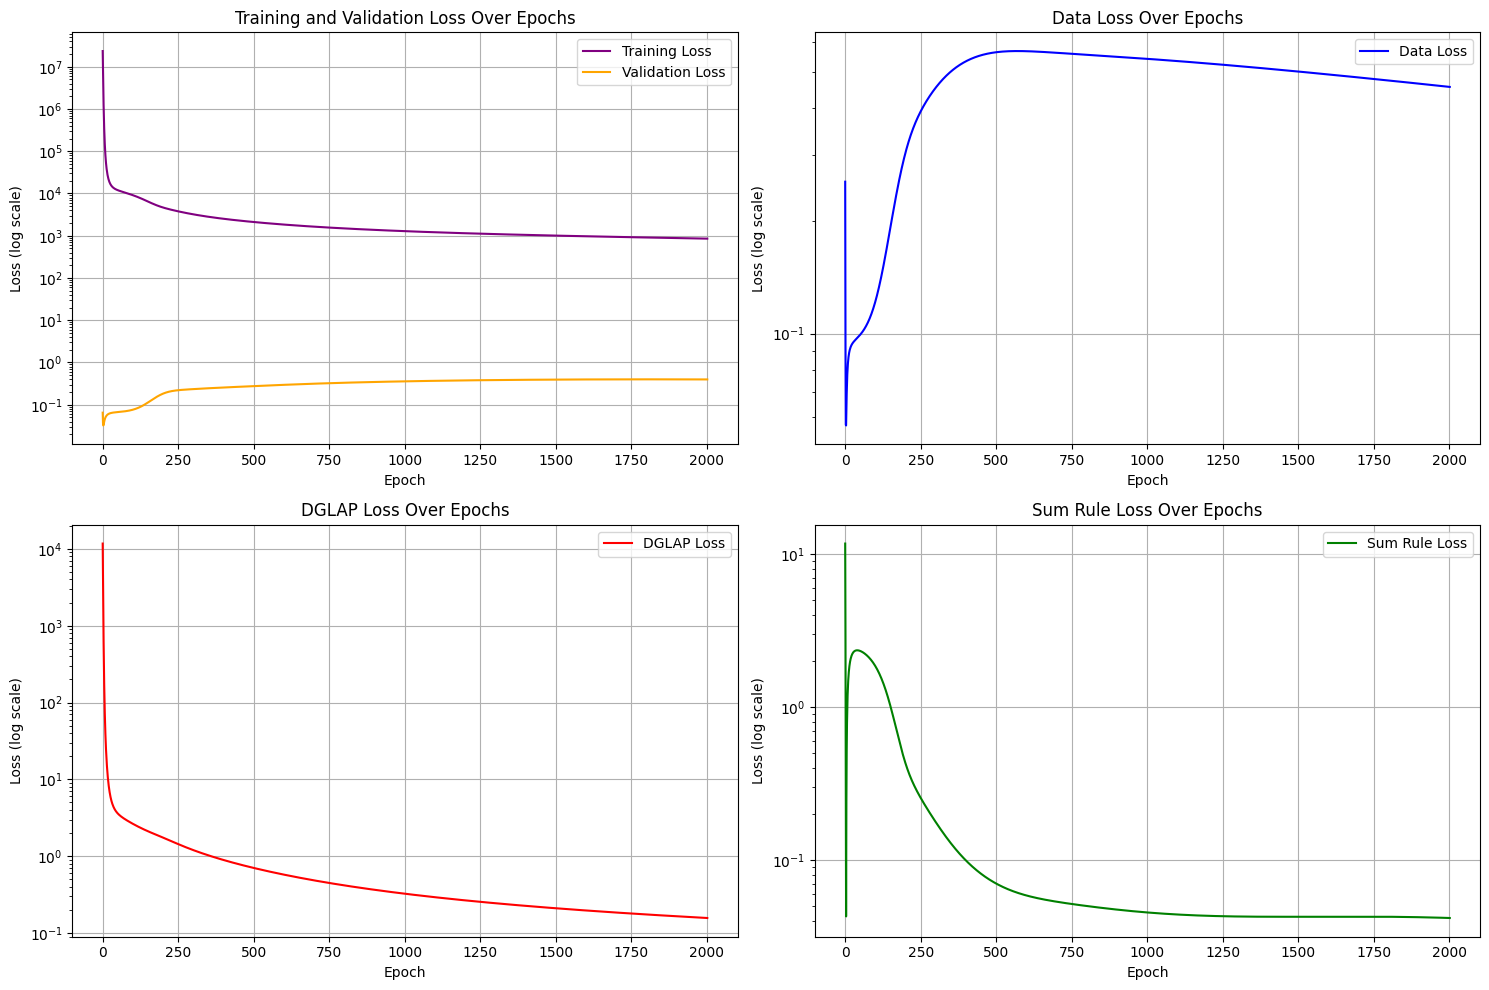

In [ ]:
fig, axes_2d = plt.subplots(2, 2, figsize=(15, 10)) # Changed to 2 rows, 2 columns
axes = axes_2d.flatten() # Flatten the axes array to ensure 1D access

# Plot Training and Validation Loss
axes[0].plot(train_losses, label='Training Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot Data Loss (Now at [0, 1])
axes[1].plot(data_losses_log, label='Data Loss', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Data Loss Over Epochs')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

# Plot Physics Loss
axes[2].plot(phys_losses_log, label='DGLAP Loss', color='red') # Changed label for clarity
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (log scale)')
axes[2].set_title('DGLAP Loss Over Epochs') # Changed title for clarity
axes[2].legend()
axes[2].grid(True)
axes[2].set_yscale('log')

# Plot Sum Rule Loss
axes[3].plot(sr_losses_log, label='Sum Rule Loss', color='green') # New subplot
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Loss (log scale)')
axes[3].set_title('Sum Rule Loss Over Epochs')
axes[3].legend()
axes[3].grid(True)
axes[3].set_yscale('log')


plt.tight_layout()
plt.show()

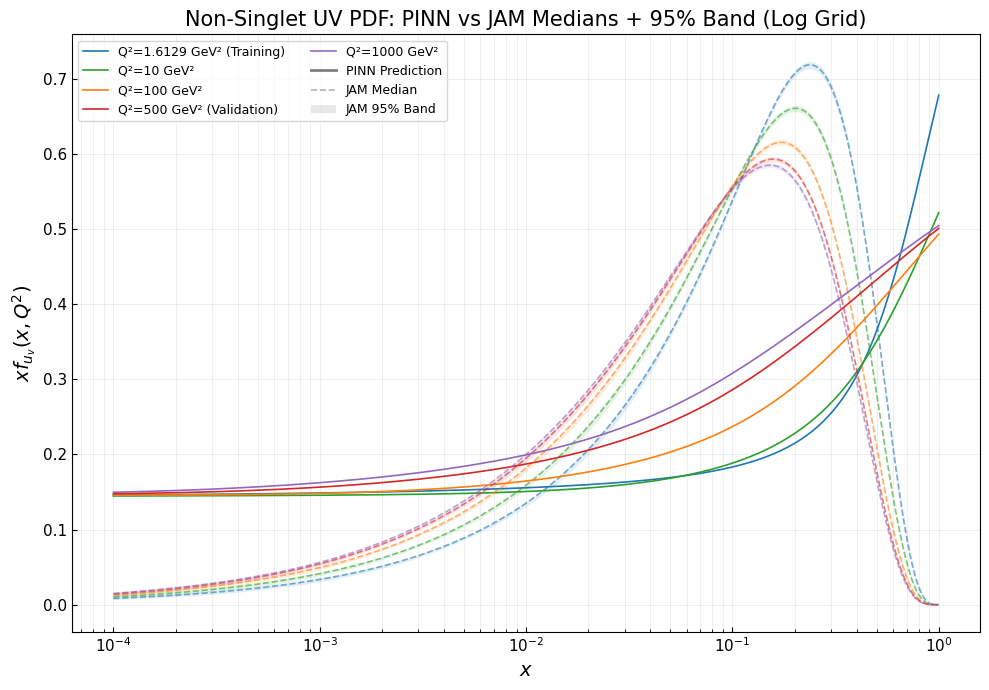

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()
log_x_np = np.log(X)

# Define colors for each Q2 scale
colors = {
    1.6129: '#1f77b4',   # blue
    10:     '#2ca02c',   # green
    100:    '#ff7f0e',   # orange
    500:    '#d62728',   # crimson
    1000:   '#9467bd',   # purple
}

fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    color = colors.get(q2, 'black')

    label_suffix = ''
    if q2 == 1.6129:
        label_suffix = ' (Training)'
    elif q2 == VAL_Q2:
        label_suffix = ' (Validation)'

    # 1. JAM 95% band (interpolated in cell 3)
    lo     = treypdf_log[q2]['uv_lo']
    hi     = treypdf_log[q2]['uv_hi']
    median = treypdf_log[q2]['uv']
    ax.fill_between(X, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(X, median, color=color, lw=1.2, ls='--', alpha=0.6)

    # 2. Network prediction
    x_np      = X # Prepare X values for input
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np = np.stack([x_np, log_x_np, log_q2_np], axis=1) # Stack X, ln(X), and ln(Q^2) as input features for prediction
    inp_t  = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    ax.plot(X, pred, color=color, lw=1.2, label=f'Q²={q2} GeV²{label_suffix}')

line_nn  = plt.Line2D([0], [0], color='grey', lw=2,
                       label='PINN Prediction')
line_med = plt.Line2D([0], [0], color='grey', lw=1.2, ls='--', alpha=0.6,
                       label='JAM Median')
line_band = plt.matplotlib.patches.Patch(facecolor='grey', alpha=0.18,
                       label='JAM 95% Band')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [line_nn, line_med, line_band],
          fontsize=9, loc='upper left', ncol=2)

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Medians + 95% Band (Log Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

plt.tight_layout()
plt.show()

The additional valence sum rule appears to have improved the shape of the model's prediction, but the PDF endpoint behavior is still not correct, as uv should be 0 at x=0 and x=1. Additionally, the model has poor generalizability as seen by the validation loss. The model repeatedly stops training around 2000 epochs due to stalled validation improvement. Is this due to architecture, data features, or hyperparameters?

## Examine the Prediction's Coverage of JAM Data

In [ ]:
# Coverage check
# 95% replica bands were already interpolated onto the log grid X in
# cell 3 (treypdf_log[q2]['uv_lo'] and 'uv_hi'). We use those directly
# here, avoiding redundant CubicSpline construction per Q2.

model.eval()
log_x_np = np.log(X)

print('Coverage within 95% JAM replica band:')
print(f'{"Q2 (GeV2)":>12} | {"Coverage":>10} | {"Set Type":>10}')
print('-' * 42)

for q2 in Q2_vals:
    # 1. Use pre-interpolated bands from cell 3
    lower = treypdf_log[q2]['uv_lo']
    upper = treypdf_log[q2]['uv_hi']

    # 2. Network prediction on X
    x_np      = X # Prepare X values for input
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np    = np.stack([x_np, log_x_np, log_q2_np], axis=1) # Stack X, ln(X), and ln(Q^2) as input features for prediction
    inp_t     = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    # 3. Coverage: fraction of x points where prediction is inside band
    inside   = (pred >= lower) & (pred <= upper)
    coverage = np.mean(inside) * 100
    set_type = 'Validation' if q2 == VAL_Q2 else 'Training'

    print(f'{q2:>12g} | {coverage:>9.1f}% | {set_type:>10}')

Coverage within 95% JAM replica band:
   Q2 (GeV2) |   Coverage |   Set Type
------------------------------------------
      1.6129 |       1.0% |   Training
          10 |       1.0% |   Training
         100 |       1.0% |   Training
         500 |       1.0% | Validation
        1000 |       1.1% |   Training
